1. Import the Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

2. Load the Dataset

In [80]:
df = pd.read_csv("../data/CICIDS2017/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [81]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225744,61326,68,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


3. Data Info

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             225745 non-null  int64  
 1    Flow Duration                225745 non-null  int64  
 2    Total Fwd Packets            225745 non-null  int64  
 3    Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets   225745 non-null  int64  
 5    Total Length of Bwd Packets  225745 non-null  int64  
 6    Fwd Packet Length Max        225745 non-null  int64  
 7    Fwd Packet Length Min        225745 non-null  int64  
 8    Fwd Packet Length Mean       225745 non-null  float64
 9    Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max         225745 non-null  int64  
 11   Bwd Packet Length Min        225745 non-null  int64  
 12   Bwd Packet Length Mean       225745 non-nul

In [83]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225745.00000,2.257450e+05,225745.000000,225745.000000,225745.000000,2.257450e+05,225745.000000,225745.000000,225745.000000,225745.000000,...,225745.000000,225745.000000,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05,2.257450e+05
mean,8879.61946,1.624165e+07,4.874916,4.572775,939.463346,5.960477e+03,538.535693,27.882221,164.826715,214.907242,...,3.311497,21.482753,1.848261e+05,1.293436e+04,2.080849e+05,1.776201e+05,1.032214e+07,3.611943e+06,1.287813e+07,7.755355e+06
std,19754.64740,3.152437e+07,15.422874,21.755356,3249.403484,3.921834e+04,1864.128991,163.324159,504.892965,797.411073,...,12.270018,4.166799,7.979250e+05,2.102737e+05,9.002350e+05,7.842602e+05,2.185303e+07,1.275689e+07,2.692126e+07,1.983109e+07
min,0.00000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.00000,7.118000e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.00000,1.452333e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,8.666667,5.301991,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,80.00000,8.805237e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,32.000000,10.263203,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239725e+06,0.000000e+00,8.253838e+06,7.422849e+06
max,65532.00000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,3867.000000,6692.644993,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


4. Check for Missing Values

In [84]:
df.isnull().sum()

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [85]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 4


In [86]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [87]:
print("Total missing values:",df.isnull().sum().sum())

Total missing values: 0


In [88]:
df.columns = df.columns.str.strip()
drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Timestamp"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

In [89]:
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [90]:
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (225711, 78)
After removing duplicates: (221264, 78)


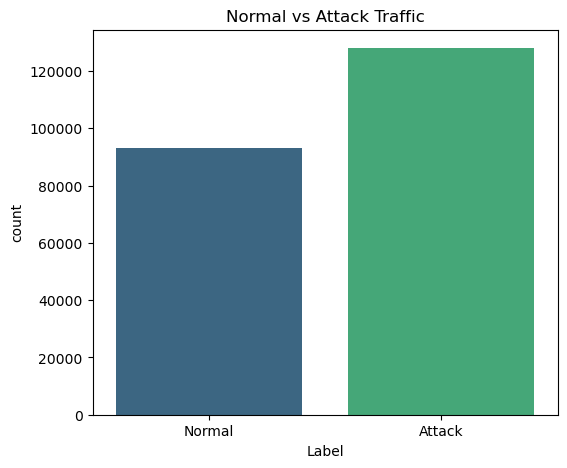

Label
1    0.578558
0    0.421442
Name: proportion, dtype: float64


In [91]:
df['Label']=df['Label'].apply(lambda x:0 if x=='BENIGN' else 1)

plt.figure(figsize=(6,5))
sns.countplot(x="Label",data=df, palette="viridis")
plt.title("Normal vs Attack Traffic")
plt.xticks([0,1],["Normal","Attack"])
plt.show()

print(df['Label'].value_counts(normalize=True))

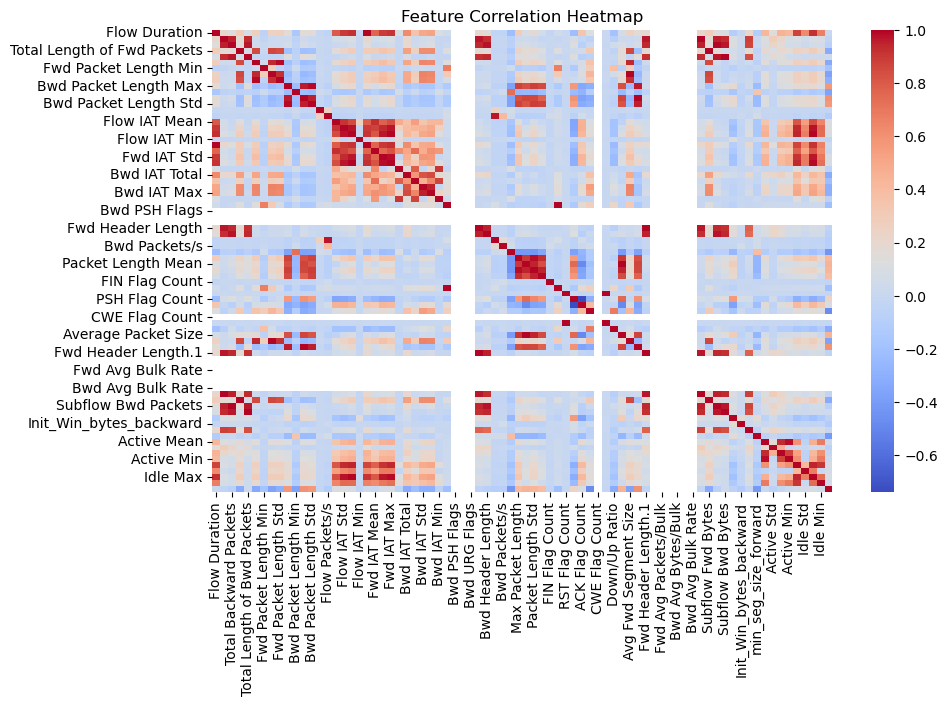

In [46]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [47]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [48]:
le = LabelEncoder()
y = le.fit_transform(y)

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

NameError: name 'train_test_split' is not defined


Logistic Regression
Train Accuracy: 0.9986
Test Accuracy: 0.9986
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     18650
      Attack       1.00      1.00      1.00     25603

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



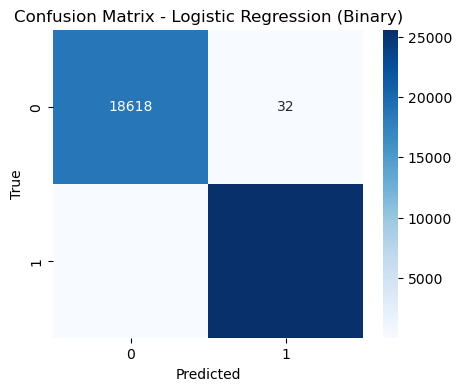


Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.9998
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     18650
      Attack       1.00      1.00      1.00     25603

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



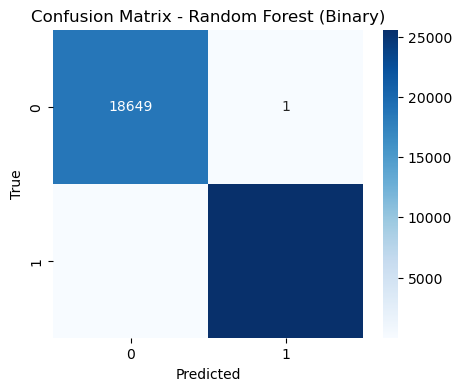


KNN
Train Accuracy: 0.9996
Test Accuracy: 0.9994
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     18650
      Attack       1.00      1.00      1.00     25603

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



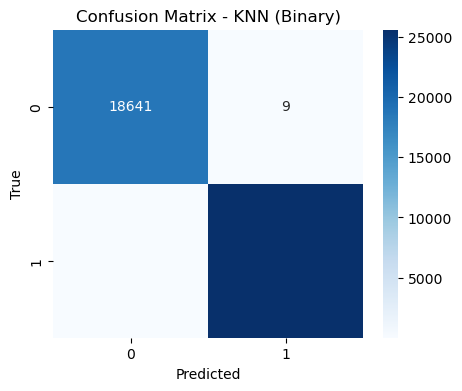

c:\Users\khush\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:42:16] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost
Train Accuracy: 1.0
Test Accuracy: 1.0
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     18650
      Attack       1.00      1.00      1.00     25603

    accuracy                           1.00     44253
   macro avg       1.00      1.00      1.00     44253
weighted avg       1.00      1.00      1.00     44253



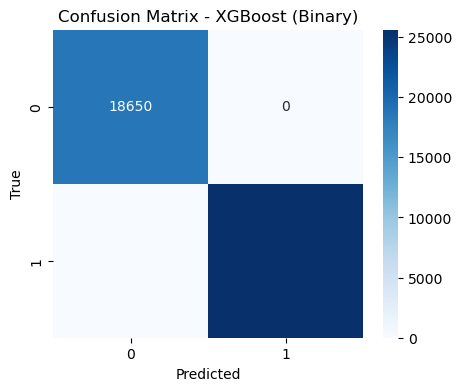

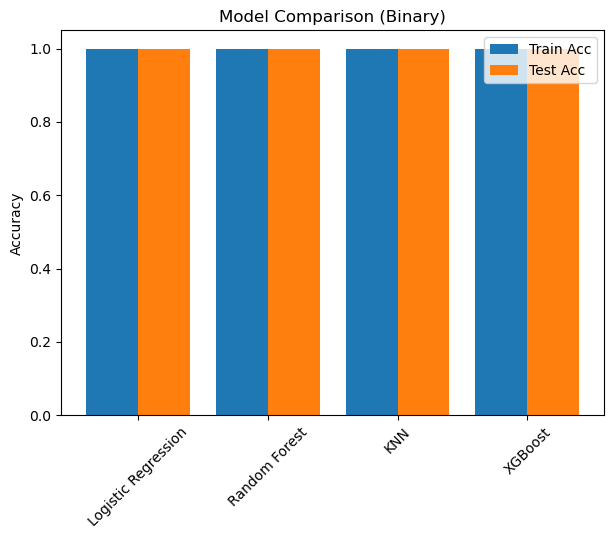

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", n_estimators=200, n_jobs=-1, random_state=42)
}

train_accs, test_accs = {}, {}

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accs[name] = train_acc
    test_accs[name] = test_acc

    print(f"\n{name}")
    print("Train Accuracy:", round(train_acc, 4))
    print("Test Accuracy:", round(test_acc, 4))
    print(classification_report(y_test, y_test_pred, target_names=["Benign","Attack"]))

    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name} (Binary)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# ---------------- Accuracy Comparison ----------------
plt.figure(figsize=(7,5))
x = np.arange(len(models))
plt.bar(x-0.2, train_accs.values(), 0.4, label="Train Acc")
plt.bar(x+0.2, test_accs.values(), 0.4, label="Test Acc")
plt.xticks(x, models.keys(), rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Binary)")
plt.legend()
plt.show()

In [ ]:
data = pd.read_csv("../data/CICIDS2017/Tuesday-WorkingHours.pcap_I")
data.columns=data.columns.str.strip()

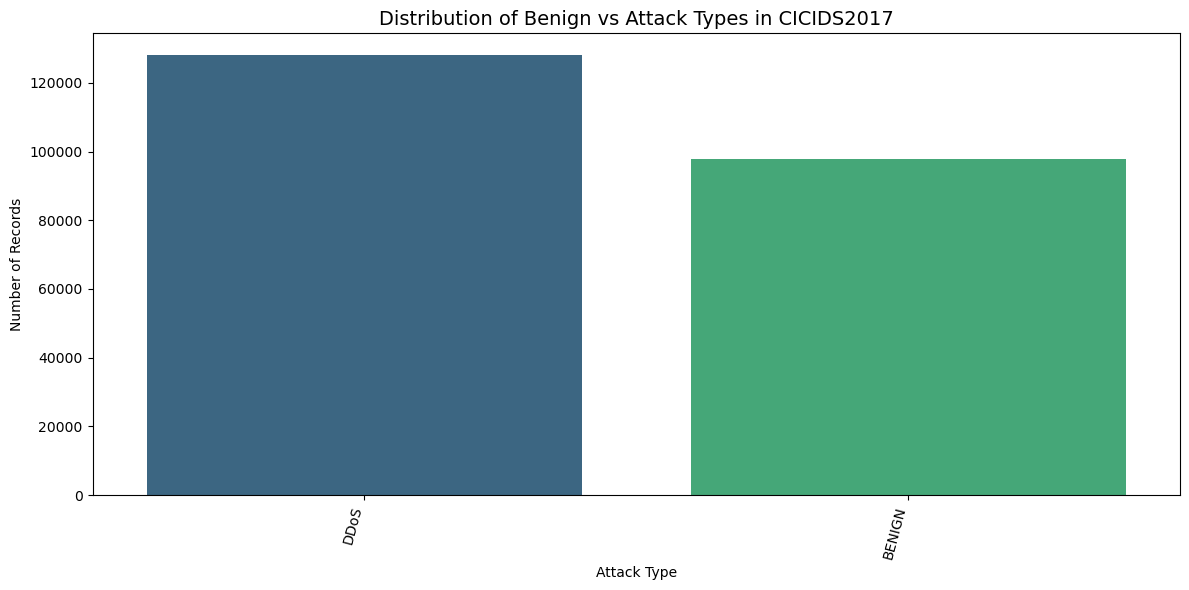

In [93]:
attack_counts = data["Label"].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=attack_counts.index, y=attack_counts.values, palette="viridis")

plt.xticks(rotation=75, ha="right")
plt.title("Distribution of Benign vs Attack Types in CICIDS2017", fontsize=14)
plt.xlabel("Attack Type")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [53]:
drop_cols = ["Flow ID", "Source IP", "Source Port", "Destination IP", "Destination Port", "Timestamp"]
data = data.drop(columns=[c for c in drop_cols if c in data.columns], errors="ignore")

In [54]:
data = data.replace([np.inf, -np.inf], np.nan).dropna()

In [55]:
X = data.drop("Label", axis=1)
y = data["Label"].str.strip()

In [56]:
le = LabelEncoder()
y = le.fit_transform(y)

In [57]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


===== Logistic Regression =====
Training Accuracy: 0.9988
Testing Accuracy: 0.9987
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



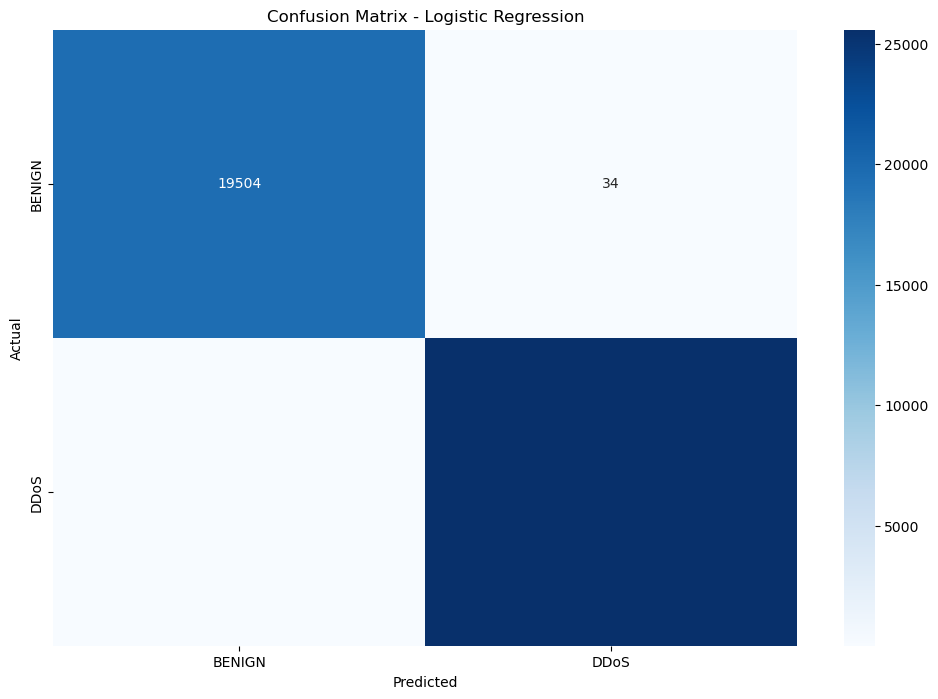


===== Random Forest =====
Training Accuracy: 1.0000
Testing Accuracy: 0.9998
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



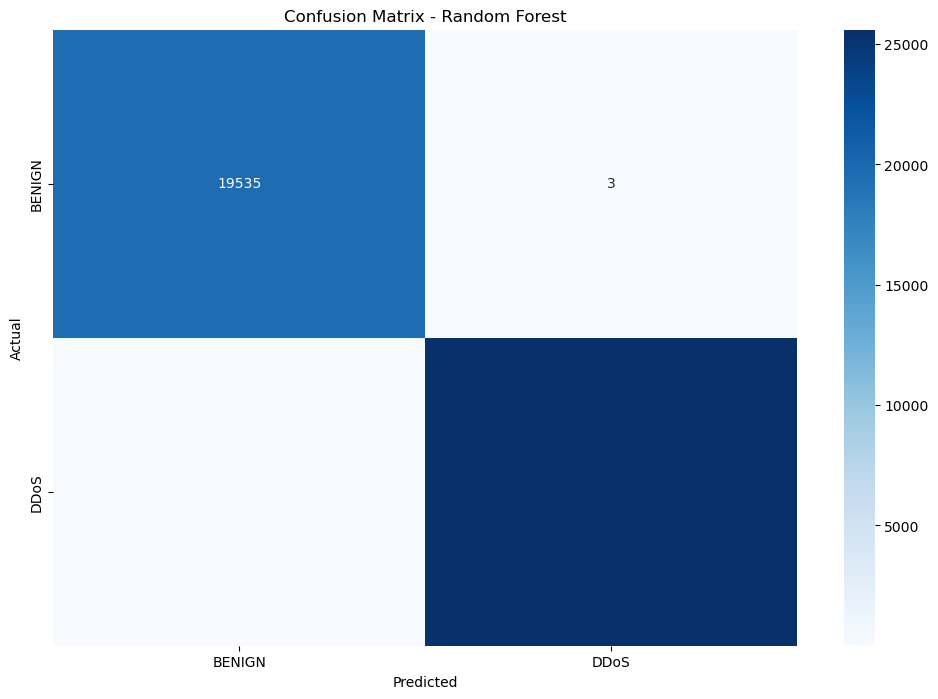


===== KNN =====
Training Accuracy: 0.9996
Testing Accuracy: 0.9994
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



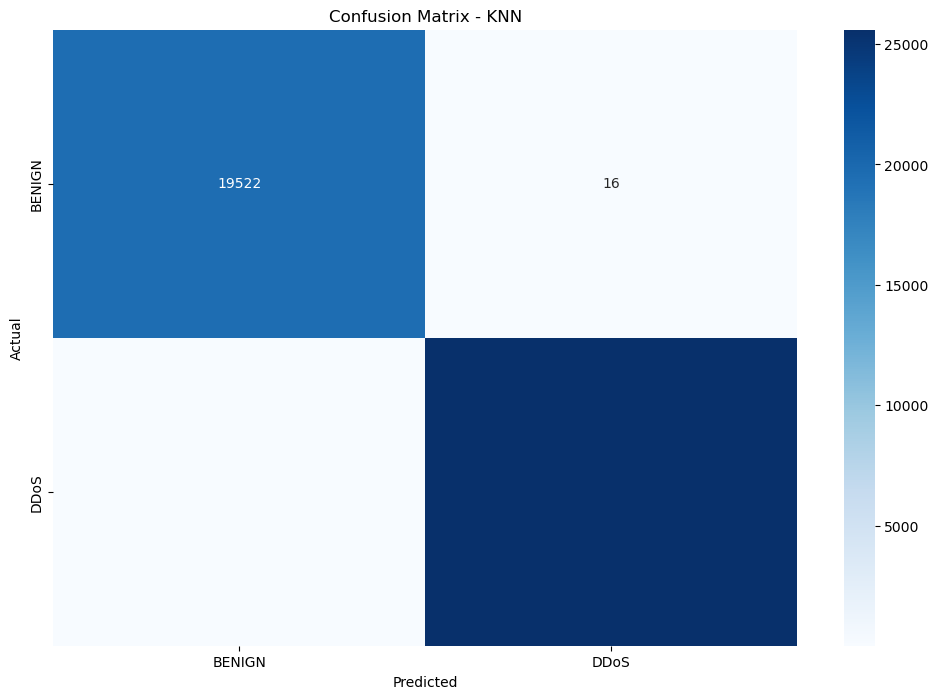


===== XGBoost =====


c:\Users\khush\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:45:29] WARNING: D:\bld\xgboost-split_1737531313485\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Training Accuracy: 1.0000
Testing Accuracy: 0.9999
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



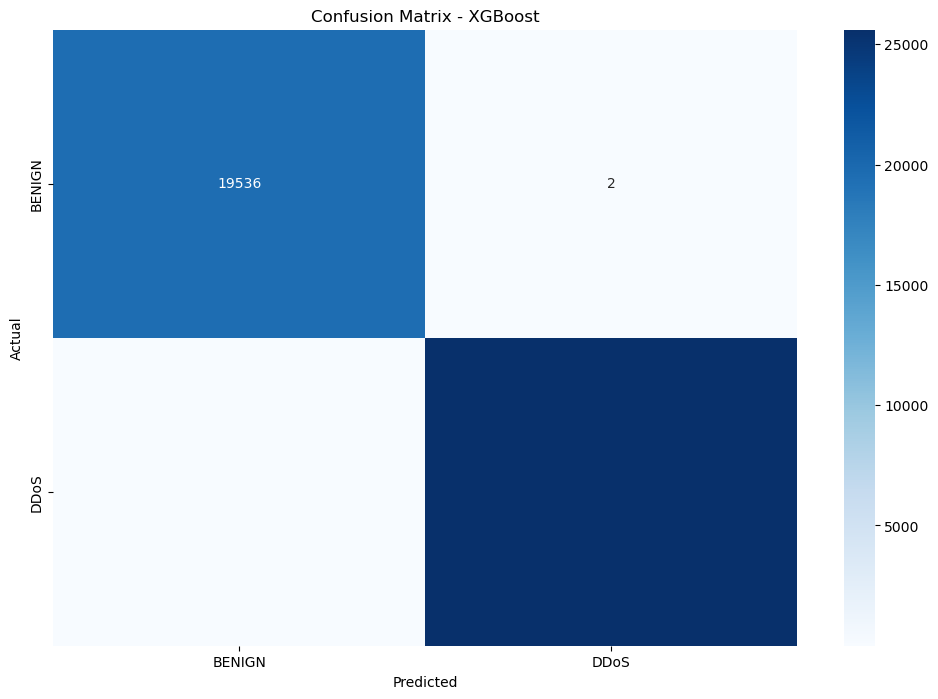

In [59]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                             n_estimators=200, n_jobs=-1, random_state=42)
}

train_accs, test_accs = {}, {}

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accs[name] = train_acc
    test_accs[name] = test_acc

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")

    # Classification Report
    class_names = [str(c) for c in le.classes_]
    print(classification_report(y_test, y_test_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred, labels=np.unique(y_test))
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

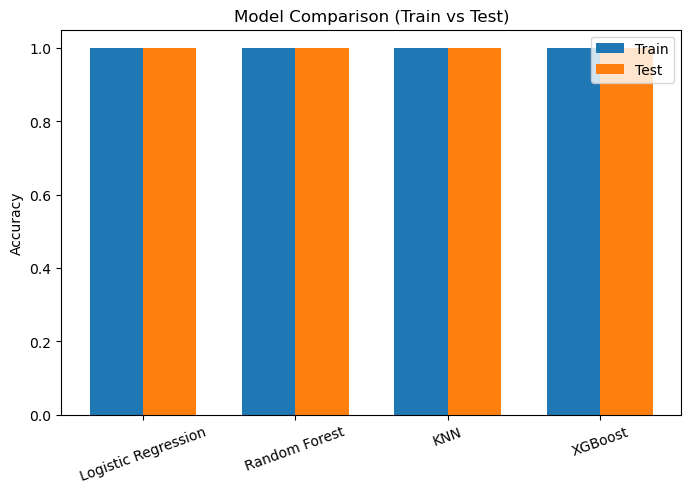

In [60]:
plt.figure(figsize=(8,5))
bar_width = 0.35
index = np.arange(len(models))

plt.bar(index, train_accs.values(), bar_width, label="Train")
plt.bar(index+bar_width, test_accs.values(), bar_width, label="Test")

plt.xticks(index + bar_width/2, list(models.keys()), rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison (Train vs Test)")
plt.legend()
plt.show()

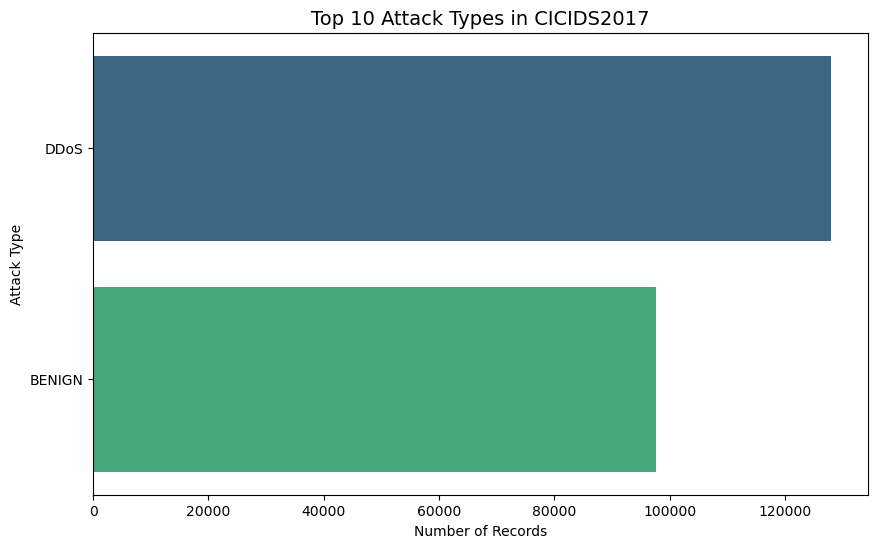

In [61]:
attack_counts = data["Label"].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette="viridis")
plt.title("Top 10 Attack Types in CICIDS2017", fontsize=14)
plt.xlabel("Number of Records")
plt.ylabel("Attack Type")
plt.show()

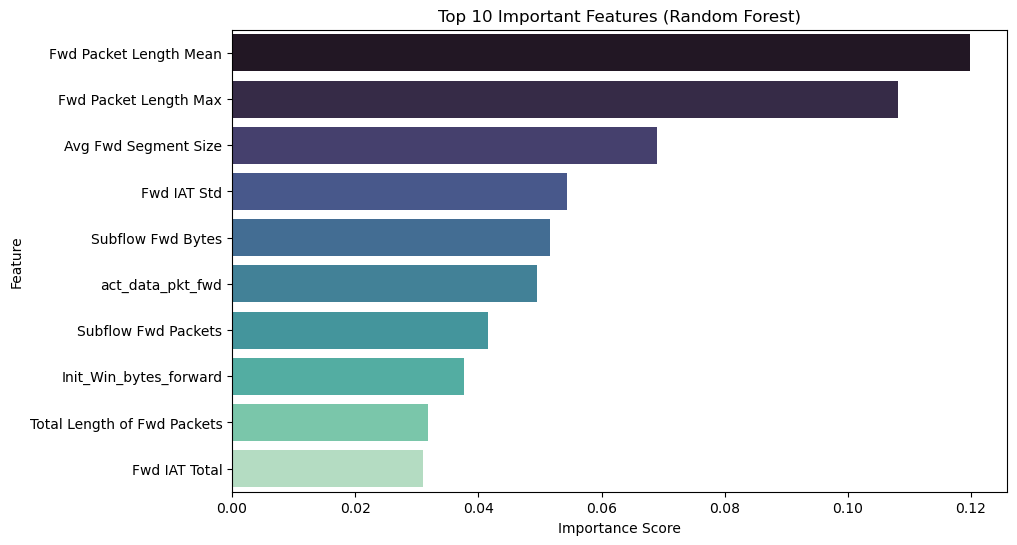

In [62]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

top_features = X.columns[indices[:10]]
top_importances = importances[indices[:10]]

plt.figure(figsize=(10,6))
sns.barplot(x=top_importances, y=top_features, palette="mako")
plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()